In [2]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv("/content/drive/MyDrive/water_purification_dataset (1).csv")

In [5]:
df.head()

,pH,turbidity_NTU,TDS_ppm,flow_rate_L_min,pressure_bar,temperature_C,usage_L_per_day,days_since_filter_change,water_quality,filter_replacement,maintenance_required
0,7.12,7.61,407,0.71,1.50,28.0,22,170,1,1,0
1,8.85,0.34,165,1.36,1.28,18.4,11,119,1,0,1
2,8.20,0.32,469,0.78,4.64,32.4,28,45,0,1,0
3,7.80,3.30,380,0.92,1.76,27.3,10,125,0,1,0
4,6.47,4.94,709,0.83,4.29,18.1,47,14,1,0,1


In [6]:
df.tail()

,pH,turbidity_NTU,TDS_ppm,flow_rate_L_min,pressure_bar,temperature_C,usage_L_per_day,days_since_filter_change,water_quality,filter_replacement,maintenance_required
1195,8.61,3.52,680,0.98,3.74,25.8,37,125,1,1,0
1196,8.92,1.63,307,0.75,3.01,17.6,32,110,1,1,0
1197,8.91,0.35,597,1.67,4.06,30.3,25,37,1,0,0
1198,8.25,6.49,435,0.68,2.94,33.6,44,21,1,1,1
1199,6.39,6.41,696,1.45,1.60,33.9,48,14,1,0,1


In [7]:
df.shape

(1200, 11)

In [8]:
df.size

13200

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pH                        1200 non-null   float64
 1   turbidity_NTU             1200 non-null   float64
 2   TDS_ppm                   1200 non-null   int64  
 3   flow_rate_L_min           1200 non-null   float64
 4   pressure_bar              1200 non-null   float64
 5   temperature_C             1200 non-null   float64
 6   usage_L_per_day           1200 non-null   int64  
 7   days_since_filter_change  1200 non-null   int64  
 8   water_quality             1200 non-null   int64  
 9   filter_replacement        1200 non-null   int64  
 10  maintenance_required      1200 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 103.3 KB


In [10]:
df.describe()

,pH,turbidity_NTU,TDS_ppm,flow_rate_L_min,pressure_bar,temperature_C,usage_L_per_day,days_since_filter_change,water_quality,filter_replacement,maintenance_required
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,7.497525,5.031892,550.088333,1.234233,2.994775,24.908417,26.638333,89.315000,1.236667,0.609167,0.384167
std,0.883788,2.850218,259.687791,0.430777,1.159019,5.763370,12.828276,52.193575,0.675304,0.488141,0.486600
min,6.010000,0.120000,100.000000,0.500000,1.000000,15.000000,5.000000,1.000000,0.000000,0.000000,0.000000
25%,6.710000,2.547500,330.250000,0.860000,1.987500,19.900000,16.000000,45.000000,1.000000,0.000000,0.000000
50%,7.530000,5.110000,550.000000,1.220000,2.945000,24.800000,26.000000,89.000000,1.000000,1.000000,0.000000
75%,8.270000,7.400000,775.250000,1.600000,3.992500,30.100000,37.000000,135.000000,2.000000,1.000000,1.000000
max,9.000000,9.990000,999.000000,2.000000,5.000000,35.000000,50.000000,179.000000,2.000000,1.000000,1.000000


In [11]:
df.isnull().sum()

,0
pH,0
turbidity_NTU,0
TDS_ppm,0
flow_rate_L_min,0
pressure_bar,0
temperature_C,0
usage_L_per_day,0
days_since_filter_change,0
water_quality,0
filter_replacement,0


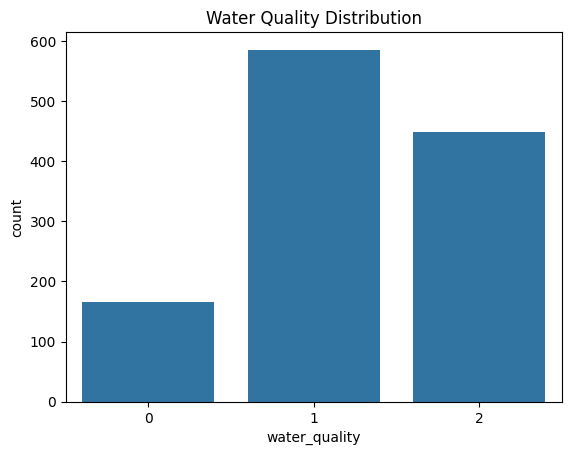

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='water_quality', data=df)
plt.title("Water Quality Distribution")
plt.show()

This helps understand range and spread of features like pH, TDS, turbidity.

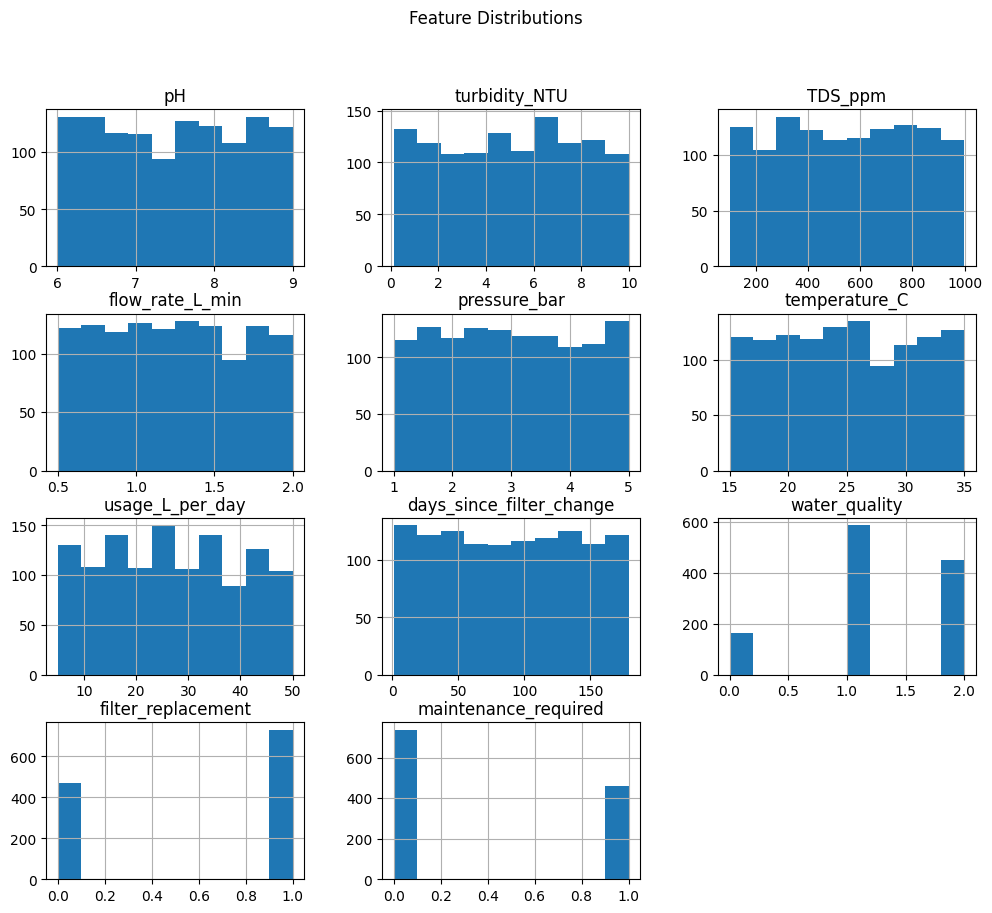

In [13]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

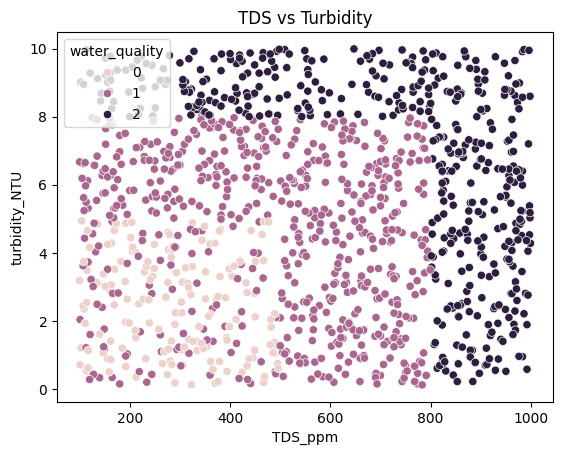

In [14]:
sns.scatterplot(x='TDS_ppm', y='turbidity_NTU', hue='water_quality', data=df)
plt.title("TDS vs Turbidity")
plt.show()

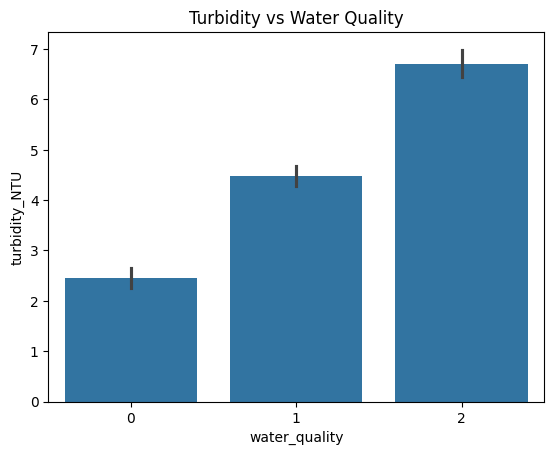

In [15]:
sns.barplot(x='water_quality', y='turbidity_NTU', data=df)
plt.title("Turbidity vs Water Quality")
plt.show()

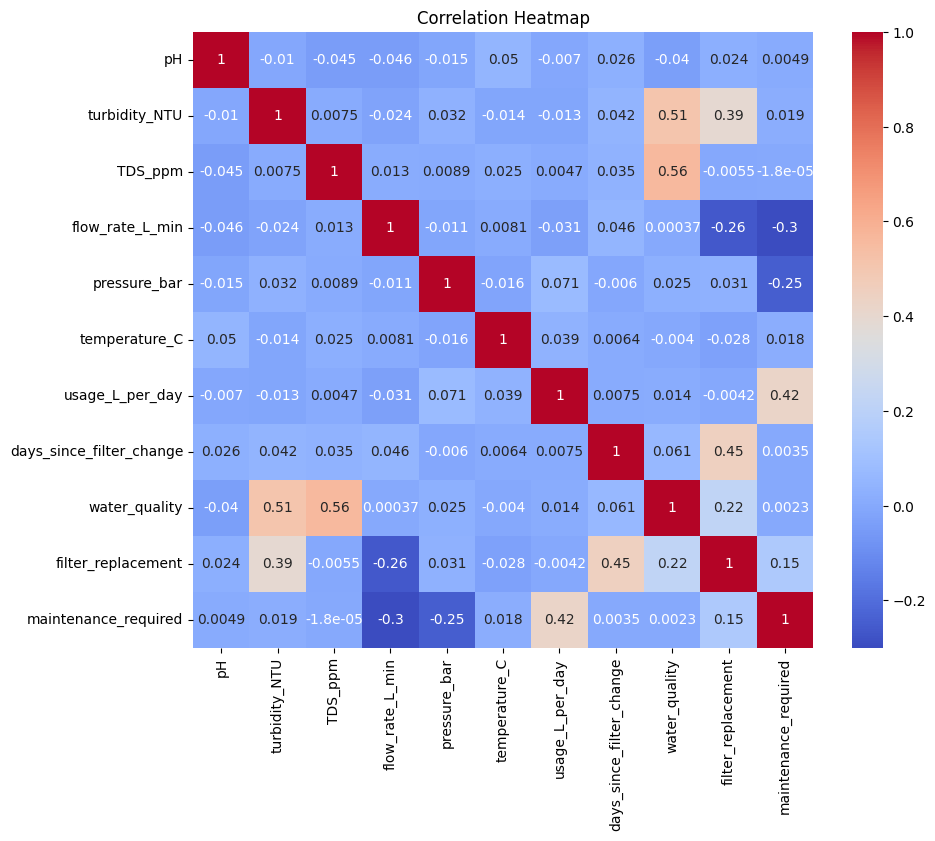

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [17]:
X = df.drop(columns=["water_quality", "filter_replacement", "maintenance_required"])
y = df["water_quality"]

In [18]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# FEATURE SCALING
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}


In [22]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [23]:
model_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    model_scores[name] = acc

    print(f"\n {name} ")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


 Logistic Regression 
Accuracy: 0.6791666666666667
              precision    recall  f1-score   support

           0       0.62      0.47      0.53        34
           1       0.64      0.74      0.69       113
           2       0.77      0.68      0.72        93

    accuracy                           0.68       240
   macro avg       0.67      0.63      0.65       240
weighted avg       0.68      0.68      0.68       240


 Decision Tree 
Accuracy: 0.9958333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      0.99      1.00       113
           2       0.99      1.00      0.99        93

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240


 Random Forest 
Accuracy: 0.9958333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      

In [24]:
best_model_name = max(model_scores, key=model_scores.get)
best_model = models[best_model_name]

print("\n Best Model:", best_model_name)
print("Best Accuracy:", model_scores[best_model_name])


 Best Model: Decision Tree
Best Accuracy: 0.9958333333333333


In [25]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)

print("\nCross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross Validation Scores: [0.984375   1.         1.         0.99479167 1.        ]
Mean CV Accuracy: 0.9958333333333332


In [26]:

# HYPERPARAMETER TUNING (ONLY FOR BEST MODEL)
if best_model_name == "Decision Tree":

    params = {
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    grid = GridSearchCV(
        DecisionTreeClassifier(),
        params,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("\nBest Parameters (Decision Tree):", grid.best_params_)
    print("Best CV Score:", grid.best_score_)

    final_model = grid.best_estimator_

elif best_model_name == "Random Forest":

    params = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }

    grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        params,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("\nBest Parameters (Random Forest):", grid.best_params_)
    print("Best CV Score:", grid.best_score_)

    final_model = grid.best_estimator_

else:
    # For Logistic Regression / AdaBoost (no tuning for simplicity)
    final_model = best_model
    final_model.fit(X_train, y_train)



Best Parameters (Decision Tree): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.9958333333333332


In [27]:
y_pred = final_model.predict(X_test)

print("\nFinal Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nFinal Classification Report:\n", classification_report(y_test, y_pred))


Final Test Accuracy: 0.9958333333333333

Final Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      0.99      1.00       113
           2       0.99      1.00      0.99        93

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



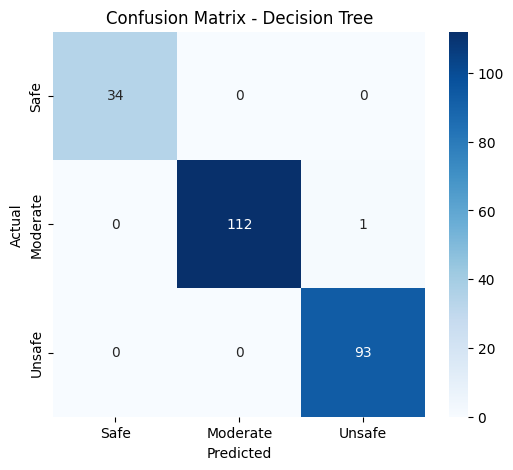

In [28]:
cm = confusion_matrix(y_test, y_pred)

labels = ["Safe", "Moderate", "Unsafe"]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
import pickle

# after training your final_model
with open("model.pkl", "wb") as f:
    pickle.dump(final_model, f)

# also save scaler (VERY IMPORTANT)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)